# TRACK-FA Interaction-Term Composite Biomarker

This legacy notebook develops the Patient-Adaptive interaction model for TRACK-FA progression.

**Model concept**

The model learns imaging weights that can vary with patient modulators such as demographic or genetic variables. Clinical scales remain benchmarks only.

**Current workflow note:** `srm_composite.ipynb` is the preferred primary notebook for reporting SRM Global Linear and Patient-Adaptive results together.


In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# Resolve project imports and data paths from either the repo root or notebooks folder.
def find_project_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "src").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError("Could not find the project root containing src/ and data/.")


_PROJECT_ROOT = find_project_root(Path.cwd())
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

from src import Config, set_global_seeds  # noqa: E402
from src.data.trackfa_pairs import infer_trackfa_feature_groups, trackfa_pairs_to_long  # noqa: E402
from src.eval.cv import group_kfold_indices, subject_loo_split  # noqa: E402
from src.eval.metrics import clinical_change_effect_sizes, paired_cohens_d, reference_effect_sizes  # noqa: E402
from src.eval.importance import bootstrap_subgroup_importance  # noqa: E402
from src.models.interaction import InteractionLinearComposite  # noqa: E402

warnings.filterwarnings("ignore")

cfg = Config(subject_col="pair_id", modulators=["GAA1", "age_at_onset", "dur", "sex"])
set_global_seeds(cfg.random_state)

DATA_PATH = cfg.processed_data_dir / "trackfa_pairs_drop3poms.csv"
print("project root      :", cfg.repo_root)
print("TRACK-FA pairs    :", DATA_PATH, "EXISTS" if DATA_PATH.exists() else "MISSING")
print("config modulators :", cfg.modulators)


project root      : /Users/robertwang/Documents/New_project/biomarkers
TRACK-FA pairs    : /Users/robertwang/Documents/New_project/biomarkers/data/processed/trackfa_pairs_drop3poms.csv EXISTS
config modulators : ['GAA1', 'age_at_onset', 'dur', 'sex']


## 1. Load and Reshape Paired Visits

This section loads processed TRACK-FA pairs and converts them into the visit-level representation needed for composite scoring.


In [2]:
data_path = DATA_PATH
print("TRACK-FA pairs   :", data_path, "EXISTS" if data_path.exists() else "MISSING")

pairs = pd.read_csv(data_path)
groups = infer_trackfa_feature_groups(pairs)
long = trackfa_pairs_to_long(pairs)

# Normalize TRACK-FA background names to the interaction model's modulator names.
long["GAA1"] = long.get("gaa_1")
long["GAA2"] = long.get("gaa_2")
long["age_at_onset"] = long.get("onset_age")
long["dur"] = long.get("disease_duration")
if "sex" in long.columns:
    long["sex"] = pd.to_numeric(long["sex"], errors="coerce")

imaging_bases = sorted(set(groups.poms + groups.brainspinemorph + groups.braindti))
imaging_bases = [b for b in imaging_bases if b in long.columns and b not in cfg.exclude_imaging]
print(f"imaging bases discovered: {len(imaging_bases)} (after exclude_imaging)")
print("long shape       :", long.shape)
print("rows per pair    :", long.groupby(cfg.subject_col).size().value_counts().to_dict())


TRACK-FA pairs   : /Users/robertwang/Documents/New_project/biomarkers/data/processed/trackfa_pairs_drop3poms.csv EXISTS
imaging bases discovered: 146 (after exclude_imaging)
long shape       : (414, 167)
rows per pair    : {2: 207}


## 2. Split Imaging Features and Patient Modulators

Imaging predictors are separated from demographic/genetic modulators. Feature selection, when used, applies only to imaging features and not to the patient modulators.


In [3]:
# Imaging predictors are paired numeric visit measures, excluding modulators and clinical scores.
non_imaging = (
    {cfg.subject_col, "visit", "FARS", "SARA", "age", "sex", "GAA1", "GAA2",
     "age_at_onset", "dur"}
    | set(cfg.modulators)
    | set(cfg.exclude_imaging)
)
imaging_cols = [c for c in imaging_bases if c not in non_imaging]
imaging_cols = [c for c in imaging_cols if c in long.columns and long[c].notna().any()]
print(f"imaging features used: {len(imaging_cols)}")

# Keep subjects with complete baseline and follow-up rows for all selected predictors.
needed = imaging_cols + list(cfg.modulators) + [cfg.subject_col, "visit"]
clean = long.dropna(subset=needed).copy()
counts = clean.groupby(cfg.subject_col)["visit"].nunique()
clean = clean[clean[cfg.subject_col].isin(counts[counts == 2].index)].reset_index(drop=True)
print("rows after pair filter :", len(clean), "subjects:", clean[cfg.subject_col].nunique())

X = clean[imaging_cols].copy()
Z = clean[list(cfg.modulators)].copy()
subject_id = clean[cfg.subject_col].copy()
visit = clean["visit"].astype(int).copy()


imaging features used: 146
rows after pair filter : 414 subjects: 207


## 3. Establish Reference Effect Sizes

Clinical and single-feature effect sizes provide context for interpreting the learned composite. These references are not training targets for the imaging composite.


In [4]:
clean_pair_ids = set(clean[cfg.subject_col].astype(str))
clinical_pairs = pairs[pairs["patient_id"].astype(str).isin(clean_pair_ids)].copy() if "patient_id" in pairs.columns else pairs.copy()

imaging_ref = reference_effect_sizes(
    clean,
    imaging_cols=imaging_cols,
    scale_cols=(),
    subject_col=cfg.subject_col,
    visit_col="visit",
)
clinical_ref = clinical_change_effect_sizes(
    clinical_pairs,
    scale_cols=("FARS", "SARA"),
    pair_types=("V1V2", "V2V3"),
)
ref = pd.concat([imaging_ref, clinical_ref], ignore_index=True)
if not ref.empty:
    ref = ref.reindex(ref["d"].abs().sort_values(ascending=False).index).reset_index(drop=True)
print("Top 8 single-feature / clinical-change paired Cohen's d (sorted by |d|):")
display(ref.head(8))


Top 8 single-feature / clinical-change paired Cohen's d (sorted by |d|):


,feature,kind,d,mean_diff,sd_diff,n_pairs,source_delta_col,pair_types
0,cerebellumFS,imaging,-0.667820,-1615.648449,2419.287337,207,NaN,NaN
1,Cerebellum_CerebNet,imaging,-0.658599,-1384.627894,2102.383322,207,NaN,NaN
2,Cerebellum_Cortex_CerebNet,imaging,-0.620381,-1189.062778,1916.666413,207,NaN,NaN
3,Cerebellum_Cortex_FS,imaging,-0.618185,-1253.672454,2027.987868,207,NaN,NaN
4,Cereb_vol,imaging,-0.564592,-1377.599034,2439.992203,207,NaN,NaN
5,Cerebellum_WM_FS,imaging,-0.560649,-361.975995,645.637084,207,NaN,NaN
6,Pons,imaging,-0.551725,-112.848907,204.538508,207,NaN,NaN
7,Whole_brainstem,imaging,-0.549968,-192.670705,350.330791,207,NaN,NaN


## 4. Evaluate Subject-Level Leave-One-Out Composites

Leave-One-Out (LOO) evaluation holds out a participant group, fits the model on the remaining participants, and scores the held-out intervals as Out-Of-Fold (OOF) predictions.


In [5]:
from dataclasses import asdict

import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler


def _paired_rows(subject_id: np.ndarray, visit: np.ndarray, v1: int = 1, v2: int = 2):
    df = pd.DataFrame({"_s": subject_id, "_v": visit})
    df["_row"] = np.arange(len(df))
    order = df.sort_values(["_s", "_v"])
    r1 = order[order["_v"] == v1][["_s", "_row"]].set_index("_s")
    r2 = order[order["_v"] == v2][["_s", "_row"]].set_index("_s")
    common = r1.index.intersection(r2.index)
    return r1.loc[common]["_row"].to_numpy(), r2.loc[common]["_row"].to_numpy(), common.to_numpy()


def _tune_delta_en_srm(Delta: np.ndarray, groups: np.ndarray, *, alpha_grid, l1_grid, n_splits: int, seed: int, eps: float):
    best = (-np.inf, None, None)
    for a in alpha_grid:
        for l1 in l1_grid:
            fold_ds = []
            for tr, va in group_kfold_indices(groups, n_splits=n_splits, seed=seed):
                m = ElasticNet(alpha=float(a), l1_ratio=float(l1), fit_intercept=False, max_iter=20000, random_state=seed)
                m.fit(Delta[tr], np.ones(len(tr)))
                dlt = Delta[va] @ m.coef_
                d = float(dlt.mean() / (dlt.std(ddof=1) + eps)) if len(dlt) >= 2 else float("nan")
                if np.isfinite(d):
                    fold_ds.append(d)
            mean_d = float(np.mean(fold_ds)) if fold_ds else float("-inf")
            if mean_d > best[0]:
                best = (mean_d, float(a), float(l1))
    if best[1] is None or best[2] is None:
        return float(cfg.interaction_en_alpha), float(cfg.interaction_en_l1_ratio)
    return float(best[1]), float(best[2])


def _fit_global_delta_model(X_train: pd.DataFrame, subject_train: np.ndarray, visit_train: np.ndarray):
    # Standardize imaging predictors using training rows only.
    xs = StandardScaler()
    Xtr = xs.fit_transform(X_train.values)

    r1, r2, common = _paired_rows(subject_train, visit_train)
    dX = Xtr[r2] - Xtr[r1]

    if cfg.interaction_tune_inner_cv:
        a, l1 = _tune_delta_en_srm(
            dX,
            common,
            alpha_grid=cfg.interaction_en_alpha_grid,
            l1_grid=cfg.interaction_en_l1_ratio_grid,
            n_splits=cfg.interaction_inner_cv_splits,
            seed=cfg.random_state,
            eps=cfg.interaction_eps,
        )
    else:
        a, l1 = float(cfg.interaction_en_alpha), float(cfg.interaction_en_l1_ratio)

    m = ElasticNet(alpha=a, l1_ratio=l1, fit_intercept=False, max_iter=20000, random_state=cfg.random_state)
    m.fit(dX, np.ones(dX.shape[0]))
    return xs, m, {"alpha": a, "l1_ratio": l1}


# Subject-level leave-one-out comparison between global and interaction composites.

rows = []
coefs_global = []
coefs_inter = []
params_global = []
params_inter = []

n_subjects = int(subject_id.nunique())
print(f"running subject-LOO over {n_subjects} subjects ...")

for fold, (train_idx, test_idx) in enumerate(subject_loo_split(subject_id.values), start=1):
    set_global_seeds(cfg.random_state)

    X_train = X.iloc[train_idx].copy()
    Z_train = Z.iloc[train_idx].copy()
    subj_train = subject_id.iloc[train_idx].values
    vis_train = visit.iloc[train_idx].values

    # Global model: imaging features only.
    xs, global_m, gp = _fit_global_delta_model(X_train, subj_train, vis_train)
    params_global.append(gp)
    coefs_global.append(global_m.coef_.copy())

    # Interaction model: imaging effects allowed to vary with patient modulators.
    inter = InteractionLinearComposite(config=cfg)
    inter.fit(X_train, Z_train, subj_train, vis_train)
    params_inter.append(inter.best_params_ or {})
    coefs_inter.append(inter.coef_.copy() if inter.coef_ is not None else np.full(1 + X.shape[1] + X.shape[1] * Z.shape[1], np.nan))

    # Score both visits for the held-out subject.
    X_test = X.iloc[test_idx].copy()
    Z_test = Z.iloc[test_idx].copy()
    subj_test = subject_id.iloc[test_idx].values
    vis_test = visit.iloc[test_idx].values

    global_scores = xs.transform(X_test.values) @ global_m.coef_
    inter_scores = inter.score(X_test, Z_test)

    for s, v, gsc, isc in zip(subj_test, vis_test, global_scores, inter_scores):
        rows.append({cfg.subject_col: s, "visit": int(v), "score_global": float(gsc), "score_inter": float(isc)})

    if fold % 5 == 0 or fold == n_subjects:
        print(f"  fold {fold:>2d}/{n_subjects}")


oof = pd.DataFrame(rows)
print("OOF rows :", len(oof))

# Summarize how often each coefficient is selected across folds.
coef_global = np.vstack(coefs_global)
sel_global = (coef_global != 0).mean(axis=0)
coef_inter = np.vstack([c for c in coefs_inter if np.all(np.isfinite(c))])
sel_inter = (coef_inter != 0).mean(axis=0) if len(coef_inter) else None

print("Global model nonzero rate (top 10):")
topg = np.argsort(-sel_global)[:10]
print(pd.DataFrame({"feature": imaging_cols, "pct_nonzero": sel_global})
        .iloc[topg].to_string(index=False))

if sel_inter is not None:
    # Name coefficients as intercept, imaging main effects, and imaging-by-modulator terms.
    p = len(imaging_cols)
    q = len(cfg.modulators)
    inter_names = [f"{x}*{z}" for x in imaging_cols for z in cfg.modulators]
    names = ["intercept"] + imaging_cols + inter_names
    topi = np.argsort(-sel_inter)[:15]
    print("Interaction model nonzero rate (top 15 including interactions):")
    print(pd.DataFrame({"term": np.array(names)[topi], "pct_nonzero": sel_inter[topi]}).to_string(index=False))


# Display coefficient stability tables for audit and plotting.
global_sel = pd.DataFrame({"term": imaging_cols, "pct_nonzero": sel_global})
inter_sel = pd.DataFrame({"term": names, "pct_nonzero": sel_inter}) if sel_inter is not None else pd.DataFrame()
params_global_df = pd.DataFrame(params_global)
params_inter_df = pd.DataFrame(params_inter)

print("Global selection frequencies:")
display(global_sel.sort_values("pct_nonzero", ascending=False).head(10))
if not inter_sel.empty:
    print("Interaction selection frequencies:")
    display(inter_sel.sort_values("pct_nonzero", ascending=False).head(15))
print("Global tuning parameters:")
display(params_global_df.head(10))
print("Interaction tuning parameters:")
display(params_inter_df.head(10))


running subject-LOO over 207 subjects ...
  fold  5/207
  fold 10/207
  fold 15/207
  fold 20/207
  fold 25/207
  fold 30/207
  fold 35/207
  fold 40/207
  fold 45/207
  fold 50/207
  fold 55/207
  fold 60/207
  fold 65/207
  fold 70/207
  fold 75/207
  fold 80/207
  fold 85/207
  fold 90/207
  fold 95/207
  fold 100/207
  fold 105/207
  fold 110/207
  fold 115/207
  fold 120/207
  fold 125/207
  fold 130/207
  fold 135/207
  fold 140/207
  fold 145/207
  fold 150/207
  fold 155/207
  fold 160/207
  fold 165/207
  fold 170/207
  fold 175/207
  fold 180/207
  fold 185/207
  fold 190/207
  fold 195/207
  fold 200/207
  fold 205/207
  fold 207/207
OOF rows : 414
Global model nonzero rate (top 10):
                feature  pct_nonzero
                 MD_gCC          1.0
       Cerebellum_WM_FS          1.0
                  AD_CP          1.0
                  FA_CP          1.0
           cerebellumFS          1.0
         bt1CSA_C12_UMN          1.0
TotalBrainGMVol_nocereb          1.0


,term,pct_nonzero
134,bt1CSA_C12_UMN,1.0
53,FA_PTR,1.0
2,AD_CP,1.0
116,RD_SCP,1.0
91,MD_gCC,1.0
40,FA_CP,1.0
28,Amygdala,1.0
126,SCP,1.0
63,FA_mLEM,1.0
136,cerebellumFS,1.0


Interaction selection frequencies:


,term,pct_nonzero
72,MD_Cing,1.000000
128,SCP_vol,1.000000
135,bt1CSA_C12_UMN,1.000000
41,FA_CP,1.000000
64,FA_mLEM,1.000000
38,Cerebellum_WM_FS,1.000000
130,TotalBrainGMVol_nocereb,1.000000
137,cerebellumFS,1.000000
117,RD_SCP,1.000000
713,sFA_c3c5*dur,1.000000


Global tuning parameters:


,alpha,l1_ratio
0,0.01,0.5
1,0.01,0.8
2,0.01,0.5
3,0.01,0.5
4,0.01,0.5
5,0.01,1.0
6,0.01,0.5
7,0.01,0.5
8,0.01,0.5
9,0.01,0.5


Interaction tuning parameters:


,alpha,l1_ratio
0,0.03,1.0
1,0.03,1.0
2,0.03,1.0
3,0.03,1.0
4,0.03,1.0
5,0.03,1.0
6,0.03,1.0
7,0.03,1.0
8,0.03,1.0
9,0.03,1.0


## 5. Compare Composite Progression Effect Sizes

This section compares learned composite `d_z` values against benchmark progression signals.


In [6]:
from scipy.stats import spearmanr


def _delta_from_oof(oof_df: pd.DataFrame, score_col: str):
    piv = oof_df.pivot(index=cfg.subject_col, columns="visit", values=score_col)
    piv = piv.dropna(subset=[1, 2], how="any")
    delta = (piv[2] - piv[1]).rename("delta")
    return delta


def _prob_superiority(delta: pd.Series) -> float:
    d = delta.dropna().values
    return float(np.mean(d > 0)) if len(d) else float("nan")


delta_g = _delta_from_oof(oof, "score_global")
delta_i = _delta_from_oof(oof, "score_inter")

# Clinical deltas are computed on the same paired subjects used by each composite.
clin = clean[[cfg.subject_col, "visit", "FARS", "SARA"]].copy()
clin = clin[clin[cfg.subject_col].isin(delta_i.index)].copy()

delta_fars = _delta_from_oof(clin.rename(columns={"FARS": "score"}), "score")
delta_sara = _delta_from_oof(clin.rename(columns={"SARA": "score"}), "score")

# Paired Cohen's d_z measures standardized within-subject change.

d_g, m_g, s_g, n_g = paired_cohens_d(oof.rename(columns={"score_global": "score"}), subject_col=cfg.subject_col, visit_col="visit", score_col="score")
d_i, m_i, s_i, n_i = paired_cohens_d(oof.rename(columns={"score_inter": "score"}), subject_col=cfg.subject_col, visit_col="visit", score_col="score")

# Add probability of superiority and correlation with clinical change.
pos_g = _prob_superiority(delta_g)
pos_i = _prob_superiority(delta_i)

def _aligned_spearman(a: pd.Series, b: pd.Series) -> float:
    ab = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
    if len(ab) < 3:
        return float("nan")
    return float(spearmanr(ab["a"], ab["b"]).correlation)

corr_fars_i = _aligned_spearman(delta_i, delta_fars)
corr_sara_i = _aligned_spearman(delta_i, delta_sara)
corr_fars_g = _aligned_spearman(delta_g, delta_fars)
corr_sara_g = _aligned_spearman(delta_g, delta_sara)

summary = pd.DataFrame([
    {"target": "Composite (global X-only)", "dz": d_g, "n": n_g, "P(Δ>0)": pos_g, "ρ(Δ,FARS)": corr_fars_g, "ρ(Δ,SARA)": corr_sara_g},
    {"target": "Composite (interaction X⊗Z)", "dz": d_i, "n": n_i, "P(Δ>0)": pos_i, "ρ(Δ,FARS)": corr_fars_i, "ρ(Δ,SARA)": corr_sara_i},
])

display(summary)

# Add benchmark rows for the best single imaging feature and adjacent clinical changes.
print()
print("Top 8 single-feature / clinical-change paired Cohen's d (sorted by |d|):")
display(ref.head(8))


,target,dz,n,P(Δ>0),"ρ(Δ,FARS)","ρ(Δ,SARA)"
0,Composite (global X-only),0.756762,207,0.768116,0.045602,0.009024
1,Composite (interaction X⊗Z),0.577337,207,0.729469,0.002240,0.036513



Top 8 single-feature / clinical-change paired Cohen's d (sorted by |d|):


,feature,kind,d,mean_diff,sd_diff,n_pairs,source_delta_col,pair_types
0,cerebellumFS,imaging,-0.667820,-1615.648449,2419.287337,207,NaN,NaN
1,Cerebellum_CerebNet,imaging,-0.658599,-1384.627894,2102.383322,207,NaN,NaN
2,Cerebellum_Cortex_CerebNet,imaging,-0.620381,-1189.062778,1916.666413,207,NaN,NaN
3,Cerebellum_Cortex_FS,imaging,-0.618185,-1253.672454,2027.987868,207,NaN,NaN
4,Cereb_vol,imaging,-0.564592,-1377.599034,2439.992203,207,NaN,NaN
5,Cerebellum_WM_FS,imaging,-0.560649,-361.975995,645.637084,207,NaN,NaN
6,Pons,imaging,-0.551725,-112.848907,204.538508,207,NaN,NaN
7,Whole_brainstem,imaging,-0.549968,-192.670705,350.330791,207,NaN,NaN


## 6. Configure Bootstrap Evaluation

Bootstrap resampling estimates uncertainty in paired Cohen's `d_z`. The interval should be interpreted cautiously when sample size is limited or intervals are not independent.


In [7]:
set_global_seeds(cfg.random_state)
full_model = InteractionLinearComposite(config=cfg)
full_model.fit(X, Z, subject_id.values, visit.values)

z_star = next(iter(cfg.subgroups.values()))
weights = full_model.imaging_weights(dict(z_star))
top10 = weights.reindex(weights.abs().sort_values(ascending=False).index).head(10)
print("Top 10 imaging weights at z* =", dict(z_star), ":")
print(top10.to_frame("beta").to_string())


Top 10 imaging weights at z* = {'age_at_onset': 10.0, 'GAA1': 500.0, 'dur': 5.0} :
                                beta
Cerebellum_WM_FS           -0.232833
cerebellumFS               -0.207162
RD_SCP                      0.197254
SCP_vol                    -0.190283
Cerebellum_Cortex_CerebNet -0.158490
Cerebellum_CerebNet        -0.155160
SCP                        -0.134313
MD_Cing                    -0.130515
Cerebellum_Cortex_FS       -0.127388
bt1CSA_C12_UMN             -0.088749


## 7. Estimate Subgroup Importance

This diagnostic checks whether patient modulators appear to influence the adaptive score. It is interpretive and should not be treated as confirmatory evidence by itself.


In [8]:
importance = bootstrap_subgroup_importance(
    model_factory=lambda: InteractionLinearComposite(config=cfg),
    X=X,
    Z=Z,
    subject_id=subject_id,
    visit=visit,
    subgroups=cfg.subgroups,
    n_boot=cfg.interaction_n_boot,
    random_state=cfg.random_state,
)
print(f"importance rows  : {len(importance)}")
print()
print("Top 5 by |mean| within first subgroup:")
first_sg = next(iter(cfg.subgroups))
view = importance[importance["subgroup"] == first_sg].copy()
view = view.reindex(view["mean"].abs().sort_values(ascending=False).index).head(5)
display(view)


importance rows  : 584

Top 5 by |mean| within first subgroup:


,feature,subgroup,mean,lo,hi,sign_consistency
547,cerebellumFS,paediatric_lowGAA,-0.432562,-1.397287,-0.027761,0.980100
151,Cerebellum_WM_FS,paediatric_lowGAA,-0.429635,-1.173047,0.000000,0.955224
467,RD_SCP,paediatric_lowGAA,0.288033,0.026524,0.604667,0.985075
515,Thalamus,paediatric_lowGAA,-0.258788,-0.894453,0.000000,0.786070
383,Midbrain,paediatric_lowGAA,-0.258706,-1.060670,0.000000,0.781095


## 8. Visualise Model Behaviour

Plots help identify whether apparent progression sensitivity is driven by broad signal, outliers, or a narrow subgroup.


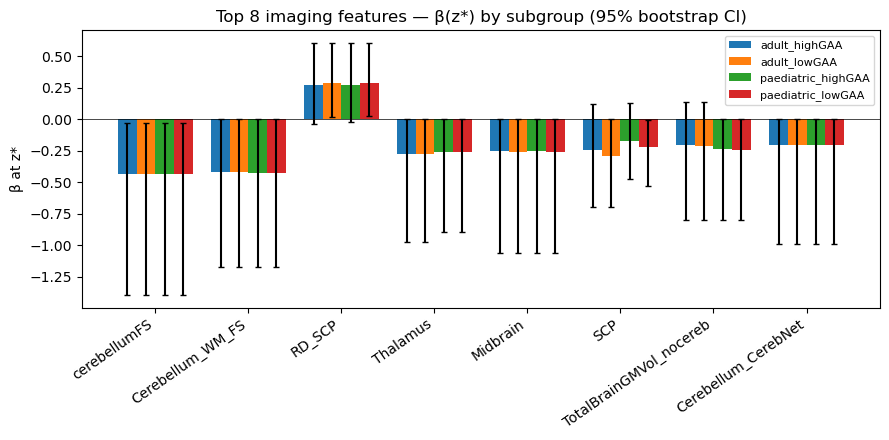

In [9]:
import matplotlib.pyplot as plt

# Plot the eight imaging features with the largest average absolute subgroup weight.
abs_mean = (
    importance.assign(abs_mean=importance["mean"].abs())
              .groupby("feature")["abs_mean"].mean()
              .sort_values(ascending=False)
)
top_feats = abs_mean.head(8).index.tolist()
plot_df = importance[importance["feature"].isin(top_feats)].copy()

if not plot_df.empty:
    pivot = plot_df.pivot(index="feature", columns="subgroup", values="mean").reindex(top_feats)
    err_lo = plot_df.pivot(index="feature", columns="subgroup", values="lo").reindex(top_feats)
    err_hi = plot_df.pivot(index="feature", columns="subgroup", values="hi").reindex(top_feats)

    subgroups_in_plot = list(pivot.columns)
    n_groups = len(subgroups_in_plot)
    bar_w = 0.8 / max(n_groups, 1)
    x = np.arange(len(top_feats))

    fig, ax = plt.subplots(figsize=(9, 4.5))
    for i, sg in enumerate(subgroups_in_plot):
        means = pivot[sg].values
        yerr_lo = np.abs(means - err_lo[sg].values)
        yerr_hi = np.abs(err_hi[sg].values - means)
        ax.bar(
            x + (i - (n_groups - 1) / 2) * bar_w,
            means,
            width=bar_w,
            yerr=[yerr_lo, yerr_hi],
            capsize=2,
            label=sg,
        )
    ax.axhline(0, color="black", lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(top_feats, rotation=35, ha="right")
    ax.set_ylabel("β at z*")
    ax.set_title("Top 8 imaging features — β(z*) by subgroup (95% bootstrap CI)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("(no importance rows to plot)")


## 9. Final Interpretation Notes

The closing cell summarises the analysis and highlights caveats for downstream reporting.


In [10]:
print("-" * 60)
print(f"n_subjects        : {n_subjects}")
print(f"n_imaging         : {len(imaging_cols)}")
print(f"n_modulators      : {len(cfg.modulators)}  ({cfg.modulators})")
print()
print("OOF paired d_z / SRM (higher is better):")
display(summary[["target", "dz", "n", "P(Δ>0)", "ρ(Δ,FARS)", "ρ(Δ,SARA)"]])


------------------------------------------------------------
n_subjects        : 207
n_imaging         : 146
n_modulators      : 4  (['GAA1', 'age_at_onset', 'dur', 'sex'])

OOF paired d_z / SRM (higher is better):


,target,dz,n,P(Δ>0),"ρ(Δ,FARS)","ρ(Δ,SARA)"
0,Composite (global X-only),0.756762,207,0.768116,0.045602,0.009024
1,Composite (interaction X⊗Z),0.577337,207,0.729469,0.002240,0.036513
